# simple multi-board sync
QICK has the following features:
* external clock: the clock reference chips on the RFSoC board can be configured to lock to an external reference (see https://docs.qick.dev/latest/_autosummary/qick.qick.html#qick.qick.QickSoc and https://docs.qick.dev/latest/topics/reference_clock.html)
* external start: the tProc can be configured to wait for an external pulse before starting execution of a program

These features can be used together to run synchronized programs on multiple boards. The general idea is that the boards are locked to a common reference, the "leader" board sends a pulse on one of the PMOD pins at the beginning of its program, and the "follower" boards are configured for external start so their tProcs only start execution when the pulse arrives at the external-start pin (another PMOD pin). The jitter between boards should be governed by the stability of the board clocks, which should be quite good (in fact we should expect that the inter-board jitter should be similar to the phase stability of individual boards).

This is very simple and the intention is that most firmwares will support it:
* any tProc v1 firmware with an external start pin - this is most firmwares
* any tProc v2 firmware with tProc revision 24 or later, and the tProc timing and core clocks coming from the same source - going forward, new firmwares will all be done this way and the standard firmwares have been updated:
    * https://s3df.slac.stanford.edu/people/meeg/qick/tprocv2/2025-06-05_111_tprocv2r24_standard/
    * https://s3df.slac.stanford.edu/people/meeg/qick/tprocv2/2025-06-15_216_tprocv2r24_standard/
    * https://s3df.slac.stanford.edu/people/meeg/qick/tprocv2/2025-06-16_216_tprocv2r24_demo/
    * https://s3df.slac.stanford.edu/people/meeg/qick/tprocv2/2025-06-15_4x2_tprocv2r24_standard/

This scheme has always been possible on tProc v1, and is based on a similar idea from Alex Ma (Purdue); what's new is:
* fixing some bugs in the tProc v2 core, now rev 24 is good
    * in rev 21 and older, external start was unstable and basically unusable
    * in rev 23 and older, DMA transfers would be unreliable if core clock was not generated from the PS clock
* adding some software hooks to allow synchronizing individual "rounds" of program execution (see https://github.com/openquantumhardware/qick/pull/342)
* this notebook, where I've tested that this all works

There are examples here for both tProc v1 and v2. They're the same, no need to run both.

In [9]:
# jupyter setup boilerplate
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

USE_LOCAL_QICK = True

if USE_LOCAL_QICK:
    import sys
    import os
    print(sys.path.insert(0,"/home/dmartin2/qick_internal_b_6_xcom/qick_lib"))
    print(sys.path)


from qick import *

None
['/home/dmartin2/qick_internal_b_6_xcom/qick_lib', '/home/dmartin2/qick_internal_b_43_testbench/qick_lib/', '/home/dmartin2/qick_internal_b_43_testbench/qick_lib/', '/home/dmartin2/qick_internal_b_43_testbench/qick_lib/', '/home/dmartin2/qick_internal_b_43_testbench/qick_lib/', '/home/dmartin2/qick_internal_b_43_testbench/qick_lib/', '/home/xilinx/jupyter_notebooks', '/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/usr/local/share/pynq-venv/lib/python3.10/site-packages', '/home/xilinx/jupyter_notebooks/qick/qick_lib', '/usr/local/lib/python3.10/dist-packages', '/usr/lib/python3/dist-packages', '/usr/lib/python3.10/dist-packages']


## tProc v2 - XCOM -
The start pulse is launched on the leader's tProc dispatcher clock and latched on the follower's tProc core clock; the follower's core then starts the dispatcher.
For this to be jitter-free, the dispatcher clock should be an integer multiple of the core clock. Until now this has not been true in the standard firmware, which has been generating the core clock from the PS clock - but easy to change.

Standard firmware with tProc r23, so you can see the problem for yourself: https://s3df.slac.stanford.edu/people/meeg/qick/tprocv2/2025-05-30_111_tprocv2r23_standard/

Jitter-free, the firmware you really should be using:
https://s3df.slac.stanford.edu/people/meeg/qick/tprocv2/2025-06-05_111_tprocv2r24_standard/

On each board (`qick1` for leader, `qick2` for follower, nameserver running on the same PC as this notebook - you could do this all differently):
```
from qick.pyro import start_server
start_server(ns_host="linux-139028.dhcp.fnal.gov", ns_port=8888, proxy_name="qick1",
             external_clk=True,
             adc_sample_rates={0:3072.0, 2:3072.0},
#              bitfile="/data/fw/2025-05-30_111_tprocv2r23_standard/qick_111.bit"
             bitfile="/data/fw/2025-06-05_111_tprocv2r24_standard/qick_111.bit"
            )
```

It doesn't matter what order you initialize the boards. Since the phase relationship between the tProc clocks is random, it's possible you will be unlucky and the sync pulse will arrive at the follower on the edge of a clock cycle, giving you a random one-tick jitter. If you see this in the results below (it's not common, seems to be less than 10% probability), re-initializing the leader or follower will fix it. (In a system with many boards, this problem scales linearly, since you just need to cycle the followers - not a big deal.)

In [ ]:
proxies = []

# from qick.pyro import make_proxy
# for name in ['qick1', 'qick2']:
#     proxies.append(make_proxy(ns_host="localhost", ns_port=8888, proxy_name=name))

# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/2025-06-15_216_tprocv2r24_standard/qick_216.bit')
# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_standard_1ch_xcom/qick_216.bit')
# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_standard_1ch_xcom_dffs/qick_216.bit')
# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_standard_1ch_260115_1/qick_216.bit')      # 1ch standard

# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_1ch_xcom_250911_1/qick_216.bit')    # fixes to XCOM
# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_1ch_xcom_250911_2/qick_216.bit')    # added ILA on AXI interface - AXI not working
# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_1ch_xcom_250911_3/qick_216.bit')      # reverted back xcom_axil_slv block
# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_1ch_xcom_250911_4/qick_216.bit')      # fixed ready resets in xcom_axil_slv
# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_1ch_xcom_250911_5/qick_216.bit')      # fixed AXI interface?
# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_1ch_xcom_251223_1/qick_216.bit')      # fixed message timing
# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_1ch_xcom_251224_1/qick_216.bit')      # added internal loopback
# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_1ch_xcom_251230_2/qick_216.bit')      # added internal loopback
# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_1ch_xcom_251230_3/qick_216.bit')      # added internal loopback
# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_1ch_xcom_260104_1/qick_216.bit')      # added internal loopback
# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_1ch_xcom_260106_3/qick_216.bit')      # added internal loopback
# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_1ch_xcom_260113_1/qick_216.bit')      # added pha autodetect
# soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_1ch_xcom_260115_1/qick_216.bit')      # added pha autodetect
soc = QickSoc('/home/xilinx/jupyter_notebooks/fw/qick_tprocv2_216_1ch_xcom_260120_1/qick_216.bit',force_init_clks=True,clk_output=True)        # fixed QICK. fixed timing


soccfg = QickConfig(soc.get_cfg())

# Append Leader Board
proxies.append( (soc, soccfg) )
# # Append Follower Board
# proxies.append( (soc, soccfg) )

for soc, soccfg in proxies:
    print(soccfg)

QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Tue Jan 20 00:12:12 2026):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	1 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0

	1 readout channels:
	0:	axis_dyn_readout_v1 - configured by tProc output 1
		fs=2457.600 Msps, decimated=307.200 MHz, 32-bit DDS, range=2457.600 MHz
		axis_avg_buffer v1.2 (has edge counter, no weights)
		memory 8192 accumulated, 4096 decimated (13.333 us)
		triggered by tport 10, pin 0, feedback to tProc input 0
		ADC tile 2, blk 0 is 0_226 on JHC7, or QICK box ADC port 4

	8 digital output pins:
	0:	PMOD0_0_LS
	1:	PMOD0_1_LS
	2:	PMOD0_2_LS
	3:	PMOD0_3_LS
	4

### Test Loaded Firmware

  0%|          | 0/10 [00:00<?, ?it/s]

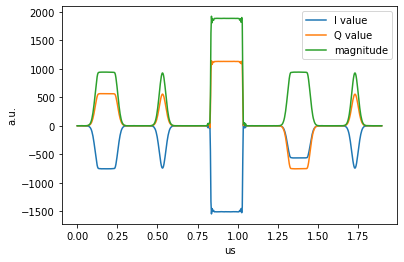

In [30]:
# the main program class
from qick.asm_v2 import AveragerProgramV2
# for defining sweeps
from qick.asm_v2 import QickSpan, QickSweep1D

# ZCU216 standard FW, full-speed gen
GEN_CH = 0
RO_CH = 0
TRIG_TIME = 0.40
FREQ = 500

class MultiPulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        ramp_len = 0.2
        self.add_gauss(ch=gen_ch, name="ramp", sigma=ramp_len/10, length=ramp_len, even_length=True)
        
        self.add_pulse(ch=gen_ch, name="myflattop", ro_ch=ro_ch, 
                       style="flat_top", 
                       envelope="ramp", 
                       freq=cfg['freq'], 
                       length=0.1,
                       phase=0,
                       gain=1.0, 
                      )

        self.add_pulse(ch=gen_ch, name="mygaus", ro_ch=ro_ch, 
                       style="arb", 
                       envelope="ramp", 
                       freq=cfg['freq'], 
                       phase=0,
                       gain=1.0, 
                      )

        self.add_pulse(ch=gen_ch, name="myconst", ro_ch=ro_ch, 
                       style="const", 
                       length=0.2, 
                       freq=cfg['freq'], 
                       phase=0,
                       gain=1.0,
                      )

        self.add_pulse(ch=gen_ch, name="myflattop2", ro_ch=ro_ch, 
                       style="flat_top", 
                       envelope="ramp", 
                       freq=cfg['freq'], 
                       length=0.1,
                       phase=90,
                       gain=1.0, 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch)
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
        
    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['gen_ch'], name="myflattop", t=0)
        self.pulse(ch=cfg['gen_ch'], name="mygaus", t=0.4)
        self.pulse(ch=cfg['gen_ch'], name="myconst", t=0.8)
        self.pulse(ch=cfg['gen_ch'], name="myflattop2", t=1.2)
        self.pulse(ch=cfg['gen_ch'], name="mygaus", t=1.6)
        
config = {'gen_ch': GEN_CH,
          'ro_ch': RO_CH,
          'freq': FREQ,
          'trig_time': TRIG_TIME,
          'ro_len': 1.9,
         }

prog = MultiPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=10)
t = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="magnitude")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

In [15]:
# Start Debug Bridge Server if present

try:
    bridge = soc._get_block('debug_bridge_0')
    # bridge_bak = getattr(soc,'debug_wrapper/debug_bridge_0') # another way to access the object
    # print(bridge)
    # bridge?

    bridge.start_xvc_server(bufferLen=4096, serverAddress="0.0.0.0", serverPort=2542, reconnect=True, verbose=True)

except:
    print('Debug blocks not found')
    


XVC server started


Connection from : ('131.225.80.73', 33300)


In [16]:
bridge.stop_xvc_server()


Client at ('131.225.80.73', 33300) disconnected by stop...
XVC server stopped


In [31]:
XCOM_CFG_POL = 1 << 8
XCOM_CFG_PHA = 1 << 9
XCOM_CFG_AUTO_PHA = 1 << 10
XCOM_CFG_LOOPBACK = 1 << 31

# xcom = soc._get_block('xcom_wrapper/xcom_0')
xcom = soc._get_block('xcom_0')
xcom.print_status()
# xcom.print_debug()

xcom.xcom_cfg = 2 | XCOM_CFG_AUTO_PHA | XCOM_CFG_LOOPBACK
print(xcom.xcom_cfg)

XCOM_ID = 2
xcom.set_local_id(XCOM_ID)
print(xcom.board_id)
# xcom.auto_id()
xcom.print_status()
# xcom.print_debug()


---------------------------------------------
--- AXI XCOM Register STATUS
 tx_st     : IDLE
 rx_st     : IDLE
 tx_ready     : 1
 board_id     : 0000
 rx_data_cntr : 0000
2147484674
2
---------------------------------------------
--- AXI XCOM Register STATUS
 tx_st     : IDLE
 rx_st     : IDLE
 tx_ready     : 1
 board_id     : 0010
 rx_data_cntr : 0010


In [32]:
XCOM_ID = 0
xcom.set_local_id(XCOM_ID)
xcom.print_status()

xcom.auto_id()
xcom.print_status()

xcom.xcom_cfg = 2 | XCOM_CFG_AUTO_PHA | XCOM_CFG_LOOPBACK
print(xcom.xcom_cfg)

# xcom.send_word(0x5555AAAA, XCOM_ID, 2)
xcom.send_word(0xAAAA5555, 0, 2)
# xcom.send_word(0x5555AAAA, 0, 2)

xcom.print_status()

## Dump XCOM memory
for i in range(16):
    xcom.axi_addr = i
    print("Memory addr: %0d - Data: %08x"%(i, xcom.mem))


---------------------------------------------
--- AXI XCOM Register STATUS
 tx_st     : IDLE
 rx_st     : IDLE
 tx_ready     : 1
 board_id     : 0000
 rx_data_cntr : 0100
---------------------------------------------
--- AXI XCOM Register STATUS
 tx_st     : IDLE
 rx_st     : IDLE
 tx_ready     : 1
 board_id     : 0110
 rx_data_cntr : 0101
2147484674
---------------------------------------------
--- AXI XCOM Register STATUS
 tx_st     : IDLE
 rx_st     : IDLE
 tx_ready     : 1
 board_id     : 0110
 rx_data_cntr : 0110
Memory addr: 0 - Data: 00000000
Memory addr: 1 - Data: 00000000
Memory addr: 2 - Data: 00000000
Memory addr: 3 - Data: 00000000
Memory addr: 4 - Data: 00000000
Memory addr: 5 - Data: 00000000
Memory addr: 6 - Data: aaaa5555
Memory addr: 7 - Data: 00000000
Memory addr: 8 - Data: 00000000
Memory addr: 9 - Data: 00000000
Memory addr: 10 - Data: 00000000
Memory addr: 11 - Data: 00000000
Memory addr: 12 - Data: 00000000
Memory addr: 13 - Data: 00000000
Memory addr: 14 - Data: 

In [ ]:
prog = MultiPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

# iq_list = []
# # iq_list = prog.acquire_decimated(soc, soft_avgs=10)
# prog.acquire_decimated(soc, rounds=5000, start_src='external', step_rounds=True)
# xcom.run_cmd(xcom.opcodes['XCOM_QCTRL'], XCOM_ID, 6)  # o_proc_start
# # xcom.print_status()
# while prog.finish_round():
#     prog.prepare_round()
#     xcom.run_cmd(xcom.opcodes['XCOM_QCTRL'], XCOM_ID, 6)  # o_proc_start
#     # xcom.print_status()

# iq_list = prog.finish_acquire()
# # print(iq_list[0][:,0])

# t = prog.get_time_axis(ro_index=0)

# plt.plot(t, iq_list[0][:,0], label="I value")
# plt.plot(t, iq_list[0][:,1], label="Q value")
# plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="magnitude")
# plt.legend()
# plt.ylabel("a.u.")
# plt.xlabel("us");

### XCOM


In [ ]:
# #Print XCOM status
if hasattr(soc, 'xcom_wrapper/xcom_0'):
    for i, (soc, soccfg) in enumerate(proxies):
        xcom = soc._get_block('xcom_wrapper/xcom_0')
        xcom.xcom_cfg = 1
        xcom.print_status()
        for i in range(8):
            # xcom.print_axi_regs()
            # xcom.print_debug()
            # xcom.set_local_id(XCOM_ID)
            # xcom.write_local_flag(1)
            xcom.run_cmd(xcom.opcodes['XCOM_QCTRL'], XCOM_ID, 7)  # o_proc_stop
            # xcom.run_cmd(xcom.opcodes['XCOM_QCTRL'], XCOM_ID, 6)  # o_proc_start
            # xcom.run_cmd(xcom.opcodes['XCOM_QCTRL'], XCOM_ID, 7)  # o_proc_stop
        xcom.print_status()


In [ ]:
# the main program class
from qick.asm_v2 import AveragerProgramV2
# for defining sweeps
from qick.asm_v2 import QickSpan, QickSweep1D

GEN_CHS = [0]
RO_CHS = [0]
TRIG_TIME = 0.35 # us
FREQ = 500

In [ ]:
class LoopbackProgramV2(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        gen_chs = cfg['gen_chs']
        for gen_ch in gen_chs:
            self.declare_gen(ch=gen_ch, nqz=1)
            # the minimum length for a waveform (i.e. either ramp of a flat-top) is 5 fabric ticks (80 DAC samples)
            # my time resolution suffers if the ramp is too slow, so I make a custom envelope
            # the ramp is only 32 samples at the start+end of the array, the middle is flat
            maxv = self.get_maxv(gen_ch)
            idata = np.ones(10*16, dtype=np.int32)*maxv
            idata[:cfg['ramp_nsamp']] = np.linspace(0, maxv, cfg['ramp_nsamp'], dtype=np.int32)
            idata[:-cfg['ramp_nsamp']-1:-1] = np.linspace(0, maxv, cfg['ramp_nsamp'], dtype=np.int32)
            qdata = np.zeros(10*16, dtype=np.int32)
            self.add_envelope(ch=gen_ch, name="ramp", idata=idata, qdata=qdata)

        self.add_pulse(ch=gen_chs,
                      name="mypulse",
                      ro_ch=ro_chs[0],
                      # style="const",
                      style="flat_top",
                      envelope="ramp",
                      freq=cfg['freq'],
                      length=cfg['pulse_len'],
                      phase=cfg['gen_phase'],
                      gain=cfg['gen_gain'],
                      )

        for ro_ch in ro_chs:
            self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_readoutconfig(ch=ro_chs,
                              name="myro",
                              freq=cfg['freq'],
                              gen_ch=gen_chs[0])

        for ro_ch in ro_chs:
            self.send_readoutconfig(ch=ro_ch,
                                   name="myro",
                                   t=0)
        if cfg['send_start']:
            self.delay(0.5)  # give processor some time to set registers
            self.trigger(pins=[0], t=0) # output a pulse on PMOD0_0, to trigger the follower
            self.delay(cfg['leader_delay']) # give follower time to catch up
        if cfg['follower_delay'] > 0:
            self.delay(cfg['follower_delay'])
                    
    def _body(self, cfg):
        self.delay(10)
        for gen_ch in cfg['gen_chs']:
            self.pulse(ch=gen_ch, name="mypulse", t=0)
        self.trigger(ros=cfg['ro_chs'], t=cfg['trig_time'])
        
config = \
{
    'gen_chs': GEN_CHS,
    'ro_chs': RO_CHS,
    'freq': FREQ,
    'trig_time': TRIG_TIME,
    'ro_len': 0.2,
    'pulse_len': 0.05,
    'ramp_nsamp': 32, # [DAC samples]
    'gen_gain': 1.0,
    'gen_phase': 0.0,
    'send_start': False,
    'leader_delay': 0.05, # [us]
    'follower_delay': 0, # [us]
}


### one board at a time

In [ ]:
progs = []
config['send_start'] = False
for i, (soc, soccfg) in enumerate(proxies):
    progs.append(LoopbackProgramV2(soccfg, reps=1, final_delay=0.5, cfg=config))
    
iq_lists = []
for i, (soc, soccfg) in enumerate(proxies):
    # Send XCOM command to start tProcs of all boards
    xcom = soc._get_block('xcom_wrapper/xcom_0')
    # iq_lists.append(progs[i].acquire_decimated(soc, progress=True, rounds=100))
    progs[i].acquire_decimated(soc, progress=True, rounds=100, start_src="external", step_rounds=True)
    # xcom.run_cmd(xcom.opcodes['XCOM_QCTRL'], 0, 7)  # o_proc_stop
    xcom.print_status()
    xcom.set_local_id(i+1)
    xcom.run_cmd(xcom.opcodes['XCOM_QCTRL'], 1, 6)  # o_proc_start
    xcom.run_cmd(xcom.opcodes['XCOM_QCTRL'], 1, 7)  # o_proc_stop
    xcom.print_status()
    while progs[i].finish_round():
        progs[i].prepare_round()
    iq_lists.append(progs[i].finish_acquire())



In [ ]:
progs[0].print_pmem2hex()

In [ ]:
fig, axes = plt.subplots(len(iq_lists), 1, figsize=(20,10))
for i, iq_list in enumerate(iq_lists):
    # plot = axes[i]
    plot = axes
    for ii, iq in enumerate(iq_list):
        plot.plot(iq[:,0], label="I value, ADC %d"%(config['ro_chs'][ii]))
        plot.plot(iq[:,1], label="Q value, ADC %d"%(config['ro_chs'][ii]))
        plot.plot(np.abs(iq.dot([1,1j])), label="mag, ADC %d"%(config['ro_chs'][ii]), marker='x')
    plot.set_ylabel("a.u.")
    plot.set_xlabel("Clock ticks")
    plot.legend();

### synchronized

In [ ]:
config['leader_delay'] = soccfg.cycles2us(22)

progs = []
for i, (soc, soccfg) in enumerate(proxies):
    config['send_start'] = (i==0)
    progs.append(LoopbackProgramV2(soccfg, reps=1, final_delay=0.5, cfg=config))

iq_lists = asyncio.run(run_multi_decimated_xcom(loop, proxies, progs, rounds=100))

# Send XCOM command to start tProcs of all boards
xcom_0 = proxies[0].soc._get_block['xcom_wrapper/xcom_0']
xcom_0.run_cmd(xcom_0.opcodes['XCOM_QCTRL'], 0, 7)  # o_proc_stop
xcom_0.run_cmd(xcom_0.opcodes['XCOM_QCTRL'], 0, 6)  # o_proc_start

fig, axes = plt.subplots(len(progs), 1, figsize=(20,10))
colors = ['blue', 'red']
for i, prog in enumerate(progs):
    plot = axes[i]
    for iq_list in prog.get_rounds():
        for ii, iq in enumerate(iq_list):
            t = 1000*prog.get_time_axis(ro_index=ii)
            plot.plot(t, get_inphase(iq), label="in-phase component, ADC %d"%(config['ro_chs'][ii]),color=colors[ii])
    plot.set_ylabel("arb. units")
    plot.set_xlabel("time [ns]")
    plot.set_title(['leader','follower'][i])

In [ ]:
# fit pulse edges
edges = np.array([[[find_edges(get_inphase(iq)) for iq in iq_list] for iq_list in prog.get_rounds()] for prog in progs])
# convert to ns
edges *= progs[0].get_time_axis(ro_index=0)[1]*1e3
# use the average of the rising and falling edges as the pulse time
pulsetimes = edges[...,:2].mean(axis=-1)

fig, axes = plt.subplots(2,2,figsize=(10,10))
for iSoc in range(2):
    plot = axes[0, iSoc]
    plot_jitter(plot, pulsetimes[iSoc,:,0], pulsetimes[iSoc,:,1])
    plot.set_xlabel("readout %d, board %d [ns]"%(0, iSoc))
    plot.set_ylabel("readout %d, board %d [ns]"%(1, iSoc))

for iRO in range(2):
    plot = axes[1, iRO]
    plot_jitter(plot, pulsetimes[0,:,iRO], pulsetimes[1,:,iRO])
    plot.set_xlabel("readout %d, board %d [ns]"%(iRO, 0))
    plot.set_ylabel("readout %d, board %d [ns]"%(iRO, 1))

## scratchwork

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(10,10))
edgename = ['rising','falling']
for iSoc in range(2):
    for iEdge in range(2):
        plot = axes[iSoc, iEdge]
        plot.plot(edges[iSoc,:,0,iEdge], edges[iSoc,:,1,iEdge], '.')
        plot.set_xlabel("readout %d, board %d, %s edge [ns]"%(0, iSoc, edgename[iEdge]))
        plot.set_ylabel("readout %d, board %d, %s edge [ns]"%(1, iSoc, edgename[iEdge]))


In [ ]:
fig, axes = plt.subplots(2,2,figsize=(10,10))
edgename = ['rising','falling']
for iRO in range(2):
    for iEdge in range(2):
        plot = axes[iRO, iEdge]
        plot.plot(edges[0,:,iRO,iEdge], edges[1,:,iRO,iEdge], '.')
        plot.set_xlabel("readout %d, board %d, %s edge [ns]"%(iRO, 0, edgename[iEdge]))
        plot.set_ylabel("readout %d, board %d, %s edge [ns]"%(iRO, 1, edgename[iEdge]))
        

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(10,10))
for iSoc in range(2):
    for iRO in range(2):
        plot = axes[iSoc, iRO]
        plot.plot(edges[iSoc,:,iRO,0], edges[iSoc,:,iRO,1], '.')
        plot.set_xlabel("readout %d, board %d, %s edge"%(iRO, iSoc, edgename[0]))
        plot.set_ylabel("readout %d, board %d, %s edge"%(iRO, iSoc, edgename[1]))
